# Model Comparison

Compares AR, ARX, ARMAX and SARIMAX, on both the filtered and unfiltered data.

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Baseline results (from the AR/ARX/ARMAX notebooks)

In [25]:
baseline = [
    {"Model": "AR", "Data": "filtered", "Order": "AR(50)", "AIC": 26099.421, "BIC": 26393.403,
     "Test MSE": 3895.26156, "Test MAE": 41.245, "Test MAPE-like": 1.582, "Test R2": 0.934},

    {"Model": "AR", "Data": "unfiltered", "Order": "AR(50)", "AIC": 46988.146, "BIC": 47315.851,
     "Test MSE": 1715.38659, "Test MAE": 20.903, "Test MAPE-like": 1.694, "Test R2": 0.973},

    {"Model": "ARX", "Data": "filtered", "Order": "ARX(46)", "AIC": 24983.253, "BIC": 25282.988,
     "Test MSE": 3980.95505, "Test MAE": 47.452, "Test MAPE-like": 1.878, "Test R2": 0.933},

    {"Model": "ARX", "Data": "unfiltered", "Order": "ARX(50)", "AIC": 45406.539, "BIC": 45765.754,
     "Test MSE": 2021.78250, "Test MAE": 33.218, "Test MAPE-like": 3.456, "Test R2": 0.968},

    {"Model": "ARMAX", "Data": "unfiltered", "Order": "(3,0,3)", "AIC": 46611.66, "BIC": 46674.797,
     "Test MSE": 4223.14087, "Test MAE": 38.169, "Test MAPE-like": 2.491, "Test R2": 0.933},

    {"Model": "ARMAX", "Data": "filtered", "Order": "(1,0,3)", "AIC": 46611.664, "BIC": 46674.797,
    "Test MSE": 6962.64971, "Test MAE": 54.889, "Test MAPE-like": 1.377, "Test R2":0.883},
    
    {"Model": "SARIMAX", "Data": "unfiltered", "Order": "(3,0,1)x(1,0,1,24)", "AIC": 44891.81, "BIC": 44967.502,
     "Test MSE": 2062.26108, "Test MAE": 21.531, "Test MAPE-like": 1.266, "Test R2":0.967},
]
baseline_df = pd.DataFrame(baseline)
baseline_df

,Model,Data,Order,AIC,BIC,Test MSE,Test MAE,Test MAPE-like,Test R2
0,AR,filtered,AR(50),26099.421,26393.403,3895.26156,41.245,1.582,0.934
1,AR,unfiltered,AR(50),46988.146,47315.851,1715.38659,20.903,1.694,0.973
2,ARX,filtered,ARX(46),24983.253,25282.988,3980.95505,47.452,1.878,0.933
3,ARX,unfiltered,ARX(50),45406.539,45765.754,2021.78250,33.218,3.456,0.968
4,ARMAX,unfiltered,"(3,0,3)",46611.660,46674.797,4223.14087,38.169,2.491,0.933
5,ARMAX,filtered,"(1,0,3)",46611.664,46674.797,6962.64971,54.889,1.377,0.883
6,SARIMAX,unfiltered,"(3,0,1)x(1,0,1,24)",44891.810,44967.502,2062.26108,21.531,1.266,0.967


## Pulling in newer models

Notebooks that save a row to `../results/model_metrics.csv` (like the SARIMAX notebook) show up here automatically, no need to re-paste numbers by hand.

In [21]:
metrics_path = "../results/model_metrics.csv"

if os.path.exists(metrics_path):
    saved_df = pd.read_csv(metrics_path)
    all_df = pd.concat([baseline_df, saved_df], ignore_index=True)
    all_df = all_df.drop_duplicates(subset=["Model", "Data"], keep="last")
else:
    all_df = baseline_df.copy()

all_df = all_df.sort_values(["Data", "Test MSE"]).reset_index(drop=True)
all_df

,Model,Data,Order,AIC,BIC,Test MSE,Test MAE,Test MAPE-like,Test R2
0,AR,filtered,AR(50),26099.421,26393.403,3895.26156,41.245,1.582,0.934
1,ARX,filtered,ARX(46),24983.253,25282.988,3980.95505,47.452,1.878,0.933
2,ARMAX,filtered,"(1,0,3)",46611.664,46674.797,6962.64971,38.169,54.889,0.883
3,AR,unfiltered,AR(50),46988.146,47315.851,1715.38659,20.903,1.694,0.973
4,ARX,unfiltered,ARX(50),45406.539,45765.754,2021.78250,33.218,3.456,0.968
5,ARMAX,unfiltered,"(3,0,3)",46611.660,46674.797,4223.14087,38.169,2.491,0.933


## Note on AIC/BIC

AIC and BIC are only comparable *within* the same dataset (filtered vs unfiltered use a different number of observations), not across the two.

## Test MSE by model

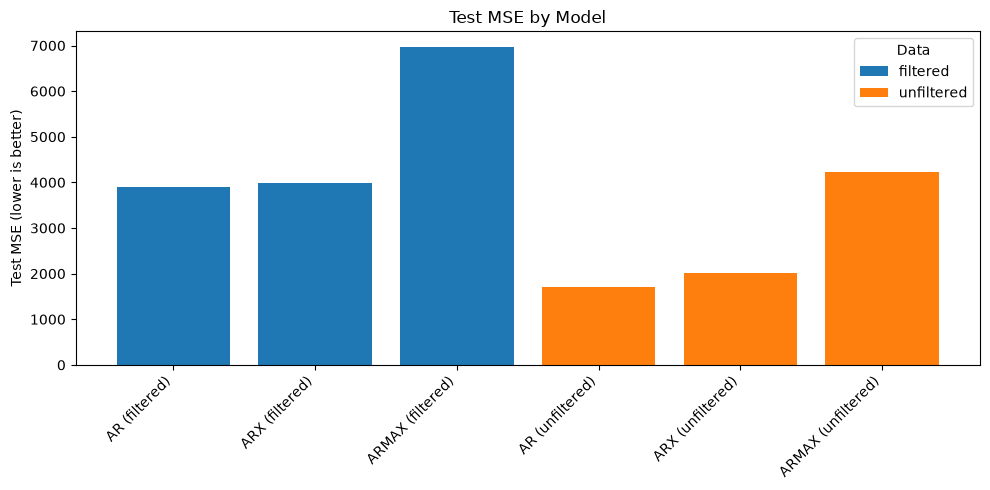

In [22]:
plot_df = all_df.dropna(subset=["Test MSE"])

fig, ax = plt.subplots(figsize=(10, 5))
for data_type, group in plot_df.groupby("Data"):
    ax.bar(
        [f"{m} ({data_type})" for m in group["Model"]],
        group["Test MSE"],
        label=data_type,
    )
plt.ylabel("Test MSE (lower is better)")
plt.title("Test MSE by Model")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Data")
plt.tight_layout()
plt.show()

## Test R² by model

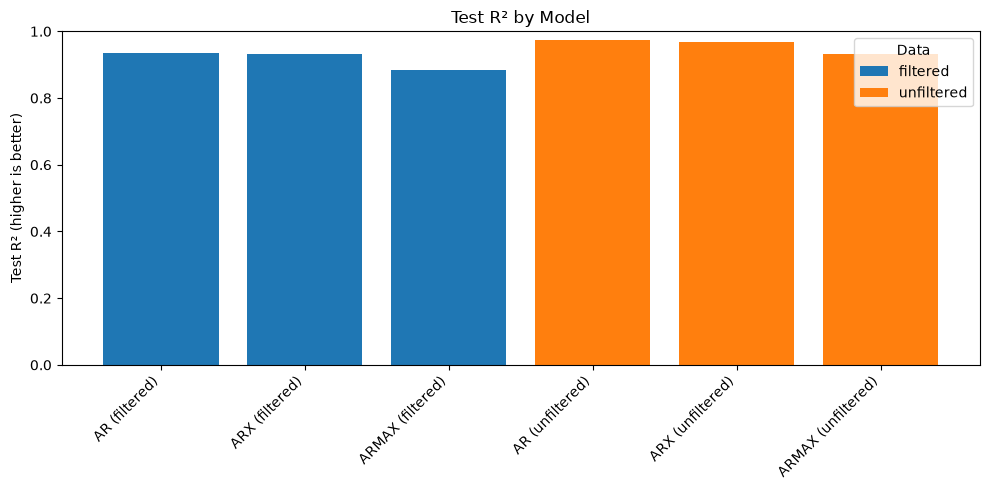

In [23]:
plot_df = all_df.dropna(subset=["Test R2"])

fig, ax = plt.subplots(figsize=(10, 5))
for data_type, group in plot_df.groupby("Data"):
    ax.bar(
        [f"{m} ({data_type})" for m in group["Model"]],
        group["Test R2"],
        label=data_type,
    )
plt.ylabel("Test R² (higher is better)")
plt.title("Test R² by Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(title="Data")
plt.tight_layout()
plt.show()

## Best model per dataset

In [24]:
best = plot_df.loc[plot_df.groupby("Data")["Test R2"].idxmax()]
best[["Model", "Data", "Order", "Test MSE", "Test MAE", "Test R2"]]

,Model,Data,Order,Test MSE,Test MAE,Test R2
0,AR,filtered,AR(50),3895.26156,41.245,0.934
3,AR,unfiltered,AR(50),1715.38659,20.903,0.973
